In [139]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os



path='D:/DATA/Projets/M1_EEG_Project/data'
# path='C:/Users/Nicolas Catz/Documents/OpenBCI_GUI/Recordings/OpenBCISession_2026-09-08_10-47-23'

filename='BrainFlow-RAW_2026-09-08_10-47-23_11.csv'
filename='openbci_simulated_N100P200_sans_entete.csv'
delim='\\t'
delim=','

data = pd.read_csv(os.path.join(path, filename),delimiter=delim, header=None)
data



,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0,-1.511032,25.559112,-19.206270,-3.383221,-9.091669,-11.006222,-16.749654,-7.166706,-0.006145,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788868e+09,0.0,2026-09-08 11:49:30.892
1,1,-3.402417,15.115210,-19.153740,-23.843458,-12.791111,-0.983815,-15.955632,-12.999931,-0.000483,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788868e+09,0.0,2026-09-08 11:49:30.896
2,2,2.411167,8.559340,-19.679049,-19.646452,-23.299752,-11.911384,-23.766722,-4.424154,-0.001858,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788868e+09,0.0,2026-09-08 11:49:30.900
3,3,2.753628,16.874434,-26.633350,-19.215728,-20.945749,-17.530391,-31.477780,-11.965916,-0.002445,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788868e+09,0.0,2026-09-08 11:49:30.904
4,4,8.370924,1.541945,-30.409659,-11.298508,-16.789664,-22.578840,-15.403440,-23.494133,0.011707,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788868e+09,0.0,2026-09-08 11:49:30.908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32495,239,-4.758865,9.932351,-25.292109,-3.418053,1.955388,-12.802850,-3.893450,4.406445,-0.002540,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788868e+09,0.0,2026-09-08 11:51:40.872
32496,240,10.888235,17.787000,-13.497411,-6.293075,4.933079,-1.656770,-2.339428,8.997315,0.009764,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788868e+09,0.0,2026-09-08 11:51:40.876
32497,241,6.040868,16.952864,-13.385026,-1.628016,5.619171,0.560179,-11.658091,4.307683,0.001894,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788868e+09,0.0,2026-09-08 11:51:40.880
32498,242,5.438534,12.809259,-15.548858,-4.693921,5.035031,3.735480,-14.084270,-9.644352,-0.004351,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.788868e+09,0.0,2026-09-08 11:51:40.884


Seuil utilisé : 0.5
Nombre de pulses TTL détectés : 118


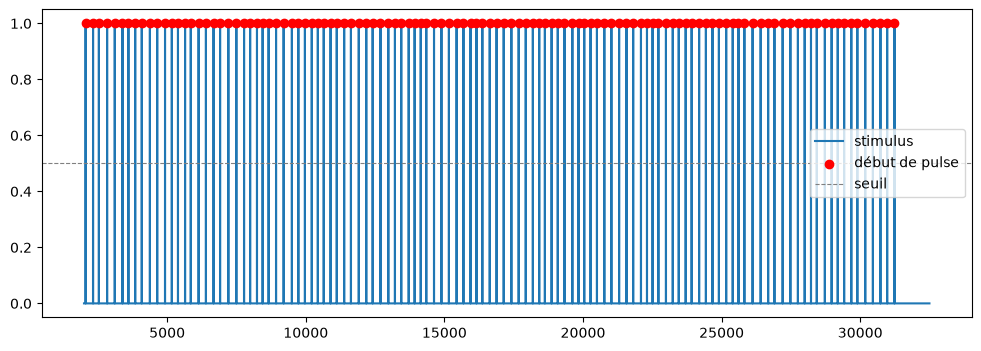

Index([ 2057,  2326,  2536,  2833,  3109,  3388,  3601,  3846,  4083,  4376,
       ...
       28968, 29188, 29419, 29677, 29895, 30180, 30456, 30728, 30971, 31234],
      dtype='int64', length=118)

In [140]:

stimulus = data[12][2000:-2] # enlever les 2000 premiers échantillons et le dernier échantillon (qui est NaN)

threshold = (stimulus.max() + stimulus.min()) / 2
above = stimulus > threshold

onset_mask = above & ~above.shift(1, fill_value=False)
onsets = stimulus.index[onset_mask]

print(f"Seuil utilisé : {threshold}")
print(f"Nombre de pulses TTL détectés : {len(onsets)}")

plt.figure(figsize=(12, 4))
plt.plot(stimulus.index, stimulus.values, label='stimulus')
plt.scatter(onsets, stimulus.loc[onsets], color='red', zorder=3, label='début de pulse')
plt.axhline(threshold, color='gray', linestyle='--', linewidth=0.8, label='seuil')
plt.legend()
plt.show()

onsets


In [141]:
from scipy.signal import butter, filtfilt, iirnotch

fs = 250
print(f"Fréquence d'échantillonnage estimée : {fs:.2f} Hz")

def bandpass_filter(sig, low=1.0, high=40.0, fs=fs, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

def notch_filter(sig, freq=50.0, fs=fs, q=30):
    nyq = fs / 2
    b, a = iirnotch(freq / nyq, q)
    return filtfilt(b, a, sig)



Fréquence d'échantillonnage estimée : 250.00 Hz


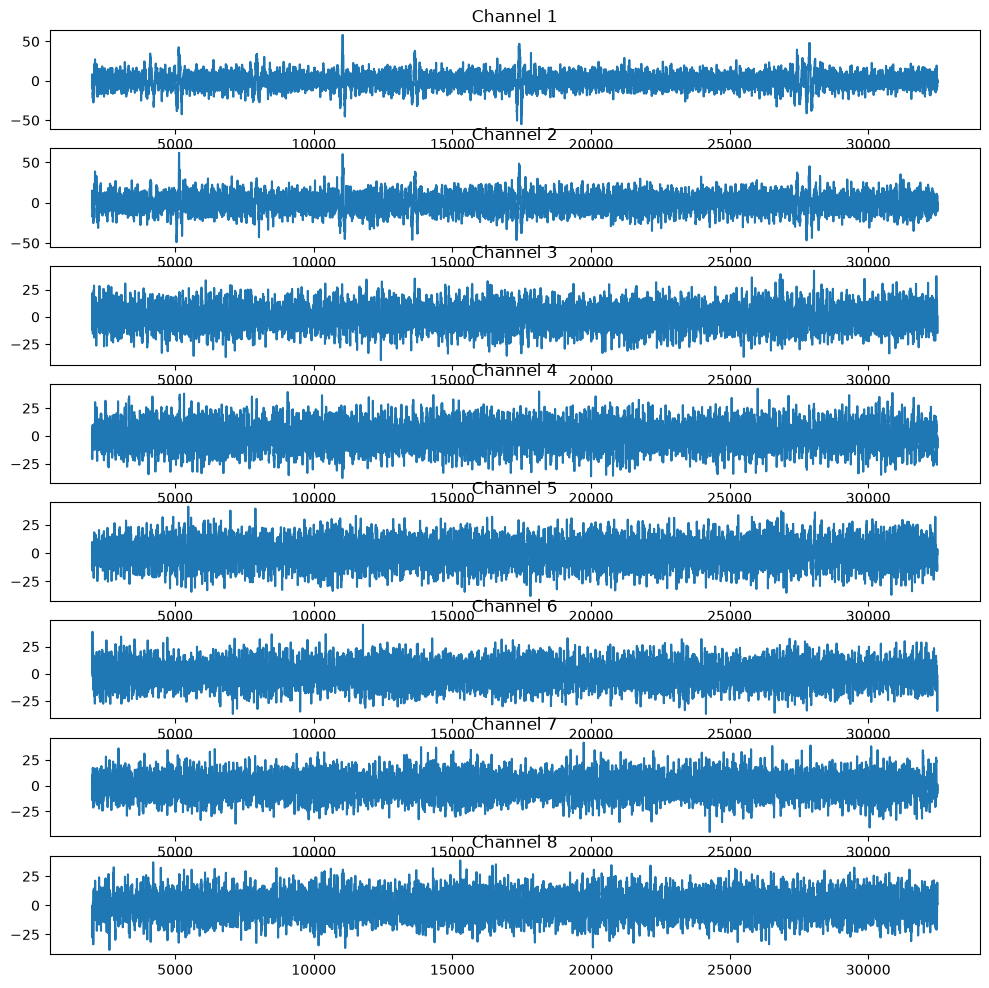

In [142]:
fig, axs = plt.subplots(8, 1, figsize=(12, 12))  

for channel in range(1,9):
    
    raw_signal = data[channel][2000:-2].to_numpy()
    eeg_filtered = notch_filter(bandpass_filter(raw_signal))
    axs[channel-1].plot(data.index[2000:-2], eeg_filtered, label=f'Channel {channel}')
    axs[channel-1].set_title(f'Channel {channel}')
    
    





Nombre d'epochs valides : 114


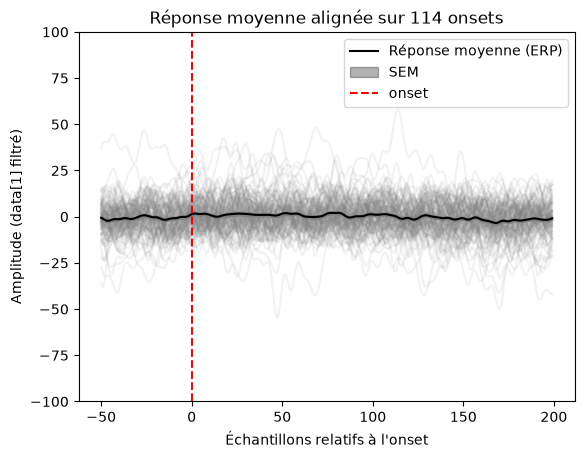

Nombre d'epochs valides : 114


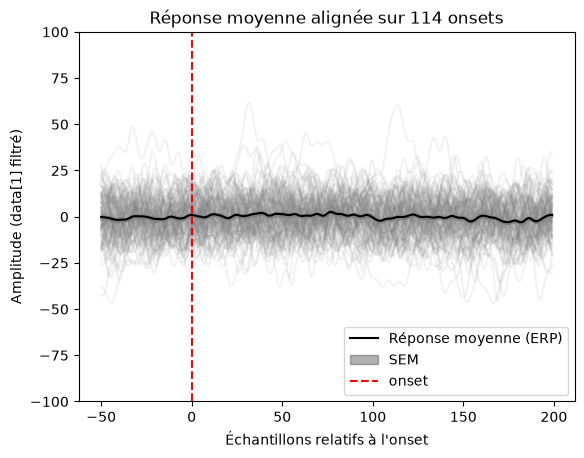

Nombre d'epochs valides : 114


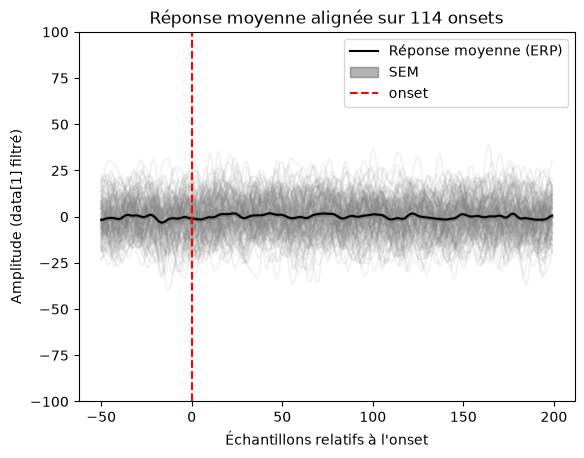

Nombre d'epochs valides : 114


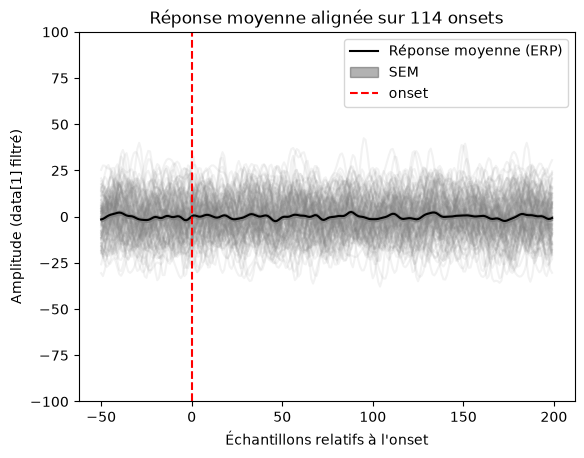

Nombre d'epochs valides : 114


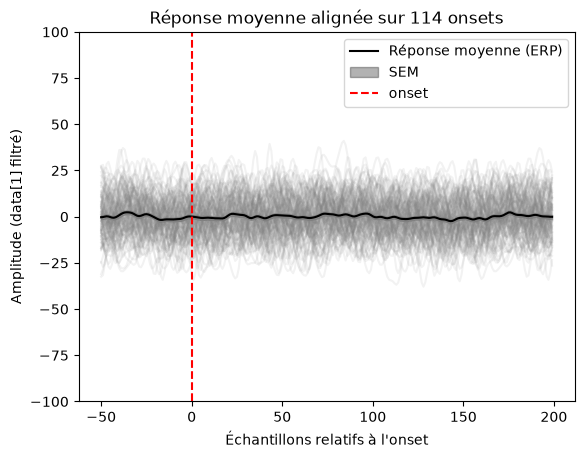

Nombre d'epochs valides : 114


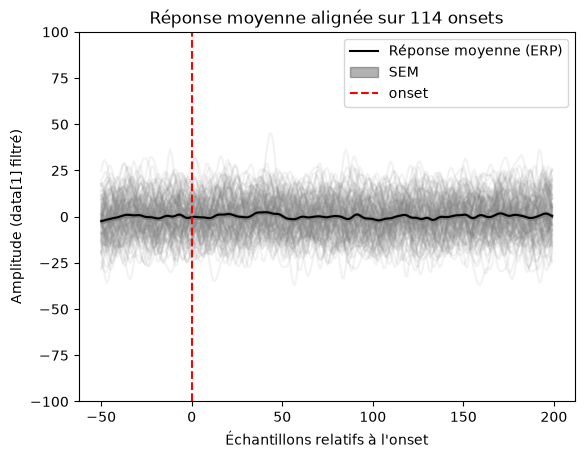

Nombre d'epochs valides : 114


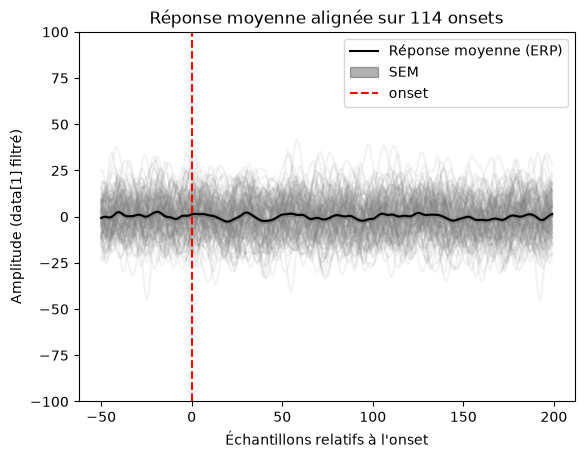

Nombre d'epochs valides : 114


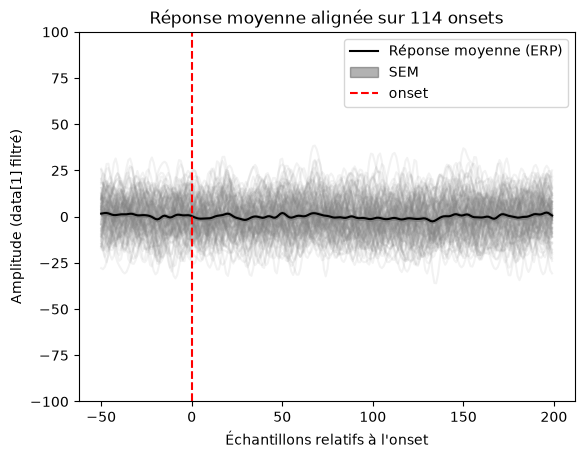

In [143]:

for channel in range(1,9):
    
    raw_signal = data[channel][2000:-2].to_numpy()
    eeg_filtered = notch_filter(bandpass_filter(raw_signal))

    signal = eeg_filtered
    onsets_arr = np.asarray(onsets)
    pre = 50   # échantillons avant l'onset
    post = 200  # échantillons après l'onset

    valid = (onsets_arr - pre >= 0) & (onsets_arr + post < len(signal))
    onsets_valid = onsets_arr[valid]

    epochs = np.stack([signal[o - pre:o + post] for o in onsets_valid])
    time = np.arange(-pre, post)

    erp = epochs.mean(axis=0)
    sem = epochs.std(axis=0) / np.sqrt(epochs.shape[0])

    print(f"Nombre d'epochs valides : {epochs.shape[0]}")

    for e in epochs:
        plt.plot(time, e, color='gray', alpha=0.1)
    plt.plot(time, erp, color='black', label='Réponse moyenne (ERP)')
    plt.fill_between(time, erp - sem, erp + sem, color='black', alpha=0.3, label='SEM')
    plt.axvline(0, color='red', linestyle='--', label='onset')
    plt.xlabel("Échantillons relatifs à l'onset")
    plt.ylabel('Amplitude (data[1] filtré)')
    plt.title(f'Réponse moyenne alignée sur {epochs.shape[0]} onsets')
    plt.legend()
    plt.ylim([-100, 100])
    plt.show()
